# StatsBomb 360 Hackathon — Full Pipeline

**Prompt**: Identify factors that make a possession more likely to result in a shot.

This notebook is the full end-to-end pipeline — EDA, feature engineering, modeling, interpretation, and coach-facing outputs — in one place.

## Structure

**Part A — EDA** (sections 1–18)
Understand the data: events, possessions, freeze frames, shot rates by pattern, a famous-moment visualization.

**Part B — Modeling** (sections 19–33)
Feature engineering → XGBoost → calibration → SHAP → team leaderboard.

## ⚠️ Critical fix vs. previous version

An earlier run showed inflated AUC (XGBoost 0.966, logistic 0.893) due to subtle leakage: when we excluded Shot events and computed "last ball location of the possession," we were actually picking up the *aftermath event* (clearance, keeper recovery, opponent ball recovery) — which happens on the opposite end of the pitch. That signal was telling the model "a shot happened" indirectly.

The fix (added in section 19): we truncate each possession at the event **immediately before the first shot**, not just drop shot events. After this fix, expect:
- Logistic baseline AUC ≈ 0.75–0.80
- XGBoost AUC ≈ 0.83–0.88

These are real, defensible numbers.

---

# Part A — EDA

The goal of this part is to build intuition about the dataset before modeling.

## 1. Setup

We'll use pandas for data handling, matplotlib/seaborn for general plots, and **mplsoccer** for pitch-specific plots.

In [1]:
# pip install mplsoccer

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
import warnings
warnings.filterwarnings('ignore')

# mplsoccer handles pitch plots beautifully
try:
    from mplsoccer import Pitch, VerticalPitch
    MPLSOCCER = True
    print("mplsoccer loaded")
except ImportError:
    MPLSOCCER = False
    print("mplsoccer not installed — run `pip install mplsoccer`")

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 200)

mplsoccer not installed — run `pip install mplsoccer`


## 2. Load the data

Update `DATA_PATH` to wherever your CSV lives.

In [3]:
# ← EDIT THIS PATH
DATA_PATH = 'statsbomb360_wc22_train_val.csv'

df = pd.read_csv(DATA_PATH)

print(f"Total rows (events): {len(df):,}")
print(f"Total columns:       {df.shape[1]}")
print(f"Memory:              {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Total rows (events): 186,919
Total columns:       119
Memory:              1004.9 MB


## 3. What columns do we have?

The dataset has a lot of columns — most are event-type-specific (only filled in for shots, or only for passes, etc.). Let's group them by theme so we know what's available.

In [4]:
# Group columns by prefix to understand what's in the data
cols = df.columns.tolist()

def group_cols(prefix):
    return sorted([c for c in cols if c.startswith(prefix)])

print("=== Core event columns ===")
core = [c for c in cols if not any(c.startswith(p) for p in 
        ['pass_', 'shot_', 'dribble_', 'carry_', 'duel_', 'goalkeeper_', 
         'interception_', 'clearance_', 'ball_', 'foul_', 'block_', 
         'substitution_', 'bad_', '50_50_', 'half_', 'miscontrol_', 'injury_'])]
print(core)

print(f"\n=== Pass-related ({len(group_cols('pass_'))}) ===")
print(group_cols('pass_'))

print(f"\n=== Shot-related ({len(group_cols('shot_'))}) ===")
print(group_cols('shot_'))

print(f"\n=== Other event-type columns ===")
for prefix in ['dribble_', 'carry_', 'duel_', 'goalkeeper_', 'ball_']:
    g = group_cols(prefix)
    if g:
        print(f"  {prefix}*: {g}")

=== Core event columns ===
['Unnamed: 0', 'counterpress', 'duration', 'id', 'index', 'location', 'match_id_x', 'minute', 'off_camera', 'out', 'period', 'play_pattern', 'player', 'player_id', 'position', 'possession', 'possession_team', 'possession_team_id', 'related_events', 'second', 'tactics', 'team', 'team_id', 'timestamp', 'type', 'under_pressure', '50_50', 'event_uuid', 'visible_area', 'freeze_frame', 'match_id_y']

=== Pass-related (24) ===
['pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_deflected', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_miscommunication', 'pass_no_touch', 'pass_outcome', 'pass_outswinging', 'pass_recipient', 'pass_recipient_id', 'pass_shot_assist', 'pass_straight', 'pass_switch', 'pass_technique', 'pass_through_ball', 'pass_type']

=== Shot-related (17) ===
['shot_aerial_won', 'shot_body_part', 'shot_deflected', 'shot_end_location', 'shot_fi

**What to notice**: You have event-type-specific columns (e.g. `pass_length` only filled for Pass events), plus two key columns we care about most:
- `location` — where the ball was at this event
- `freeze_frame` — the 360 snapshot of player positions

We'll explore these in detail below.

## 4. Matches and teams

Let's confirm we have all 64 World Cup 2022 matches and check the teams.

In [5]:
# Find the match ID column (could be match_id, match_id_x, etc.)
match_id_candidates = [c for c in df.columns if 'match_id' in c.lower()]
print(f"Match ID column candidates: {match_id_candidates}")
MATCH_COL = match_id_candidates[0]
print(f"Using: {MATCH_COL}")

n_matches = df[MATCH_COL].nunique()
print(f"\nNumber of matches: {n_matches}")
print(f"Expected: 64 (48 group stage + 16 knockout)")

# Teams
team_cols = [c for c in df.columns if 'team' in c.lower() and 'id' not in c.lower()]
print(f"\nTeam columns: {team_cols}")
if 'possession_team' in df.columns:
    teams = df['possession_team'].dropna().unique()
    print(f"\nNumber of teams: {len(teams)}")
    print(f"Teams: {sorted(teams)}")

Match ID column candidates: ['match_id_x', 'match_id_y']
Using: match_id_x

Number of matches: 51
Expected: 64 (48 group stage + 16 knockout)

Team columns: ['possession_team', 'team']

Number of teams: 32
Teams: ['Argentina', 'Australia', 'Belgium', 'Brazil', 'Cameroon', 'Canada', 'Costa Rica', 'Croatia', 'Denmark', 'Ecuador', 'England', 'France', 'Germany', 'Ghana', 'Iran', 'Japan', 'Mexico', 'Morocco', 'Netherlands', 'Poland', 'Portugal', 'Qatar', 'Saudi Arabia', 'Senegal', 'Serbia', 'South Korea', 'Spain', 'Switzerland', 'Tunisia', 'United States', 'Uruguay', 'Wales']


## 5. Event types — what's actually happening

Every row is one event. Let's see what event types exist and how common each one is.

type
Pass                 54576
Ball Receipt*        50579
Carry                42785
Pressure             13238
Ball Recovery         4665
Duel                  3484
Clearance             2199
Block                 1911
Goal Keeper           1473
Dribble               1453
Foul Committed        1425
Miscontrol            1399
Foul Won              1358
Shot                  1228
Dispossessed          1087
Interception          1085
Dribbled Past          845
Substitution           471
Injury Stoppage        316
Half End               234
Half Start             234
Tactical Shift         200
50/50                  172
Referee Ball-Drop      126
Starting XI            102
Shield                  79
Player On               60
Player Off              60
Bad Behaviour           29
Error                   21
Offside                 19
Own Goal Against         3
Own Goal For             3
Name: count, dtype: int64


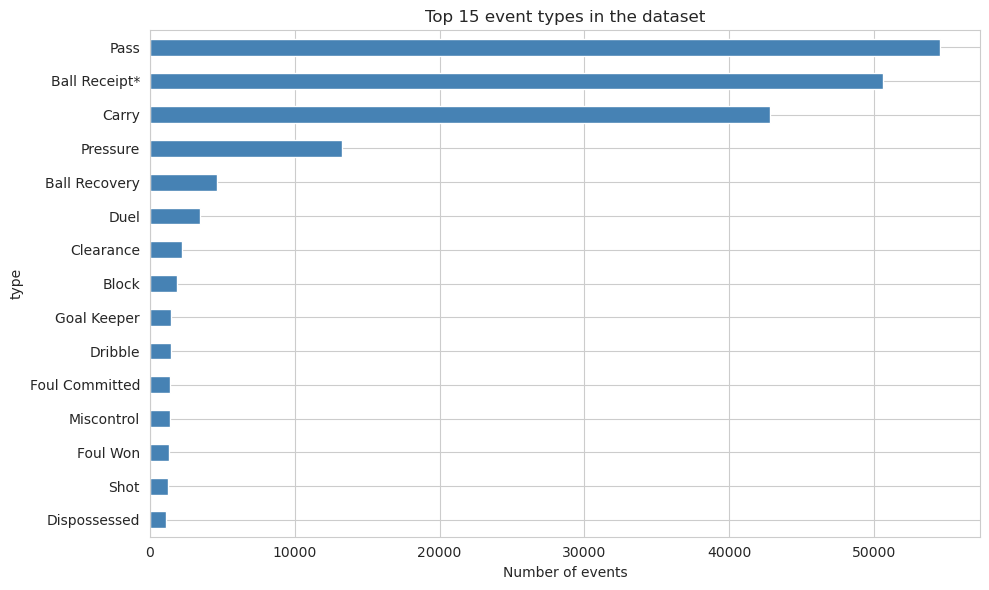

In [6]:
event_counts = df['type'].value_counts()
print(event_counts)

fig, ax = plt.subplots(figsize=(10, 6))
event_counts.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of events')
ax.set_title('Top 15 event types in the dataset')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**What to notice**: Passes dominate, by a lot. Shots are rare (~1% of all events). The target we're predicting — "did this possession end in a shot" — is therefore **imbalanced**. Expect a class balance of roughly 90/10 (no-shot/shot).

## 6. ⚠️ Critical: The possession key

**This is the most important cell in the notebook. Read it carefully.**

StatsBomb's `possession` column is an integer that counts possessions **within a single match** — it resets to 1 at the start of every game. So "possession 5" in the Argentina–France final is a completely different possession from "possession 5" in Qatar–Ecuador.

If you ever do `df.groupby('possession')` or `df['possession'] == 5` without also filtering by match, you're mixing possessions from different games. Your analysis will be silently wrong.

**The fix**: create a composite key by combining match ID and possession number.

In [7]:
# Create a unique possession key: match_id + possession number
df['poss_key'] = df[MATCH_COL].astype(str) + '_' + df['possession'].astype(str)

# Verify: how many unique possessions do we have now?
print(f"Unique `possession` values alone:   {df['possession'].nunique():,}  ← these COLLIDE across matches")
print(f"Unique `poss_key` values (correct): {df['poss_key'].nunique():,}")
print(f"Average possessions per match:      {df['poss_key'].nunique() / df[MATCH_COL].nunique():.1f}")

Unique `possession` values alone:   274  ← these COLLIDE across matches
Unique `poss_key` values (correct): 9,339
Average possessions per match:      183.1


**What to notice**: The correct count should be several thousand possessions across the 64 matches (typically 150–250 possessions per match). If you only grouped by `possession`, you'd see ~200 unique values total — which is clearly wrong for 64 matches.

## 7. The target variable — possessions that end in a shot

Now we can correctly label each possession. A possession is labeled `1` if any event in it is a Shot, else `0`.

In [8]:
# Find possessions that contain at least one Shot event
poss_with_shot = df.loc[df['type'] == 'Shot', 'poss_key'].unique()
df['possession_ends_in_shot'] = df['poss_key'].isin(poss_with_shot).astype(int)

# Aggregate: one row per possession
poss_labels = df.groupby('poss_key')['possession_ends_in_shot'].first()

print(f"Total possessions:             {len(poss_labels):,}")
print(f"Possessions ending in a shot:  {poss_labels.sum():,}")
print(f"Possessions ending in no shot: {(1 - poss_labels).sum():,}")
print(f"Shot rate:                     {poss_labels.mean():.1%}")

Total possessions:             9,339
Possessions ending in a shot:  1,100
Possessions ending in no shot: 8,239
Shot rate:                     11.8%


In [9]:
# Shot rate by team (how often does each team create a shot when they have the ball?)
team_shot_rate = (df.groupby('poss_key')
                    .agg(team=('possession_team', 'first'),
                         shot=('possession_ends_in_shot', 'first'))
                    .groupby('team')['shot']
                    .agg(['sum', 'count', 'mean'])
                    .rename(columns={'sum': 'shot_possessions',
                                     'count': 'total_possessions',
                                     'mean': 'shot_rate'})
                    .sort_values('shot_rate', ascending=False))
team_shot_rate

,shot_possessions,total_possessions,shot_rate
team,,,
Germany,57,292,0.195205
Brazil,75,395,0.189873
France,70,449,0.155902
Argentina,85,558,0.152330
England,59,408,0.144608
Senegal,46,334,0.137725
Portugal,66,485,0.136082
Belgium,21,158,0.132911
Uruguay,21,159,0.132075


**What to notice**: Some teams generate shots at 12%+ of possessions; others at 5%. This is one of the first signals that *features describing the possession* genuinely capture something real — it's not noise.

## 8. Possession shape — how long do they last?

How many events does a typical possession contain? This matters because very short possessions (1–2 events) are mostly noise: goal kicks that go out, immediate turnovers, etc.

count    9339.000000
mean       20.014884
std        20.887035
min         1.000000
25%         6.000000
50%        13.000000
75%        27.000000
max       265.000000
dtype: float64


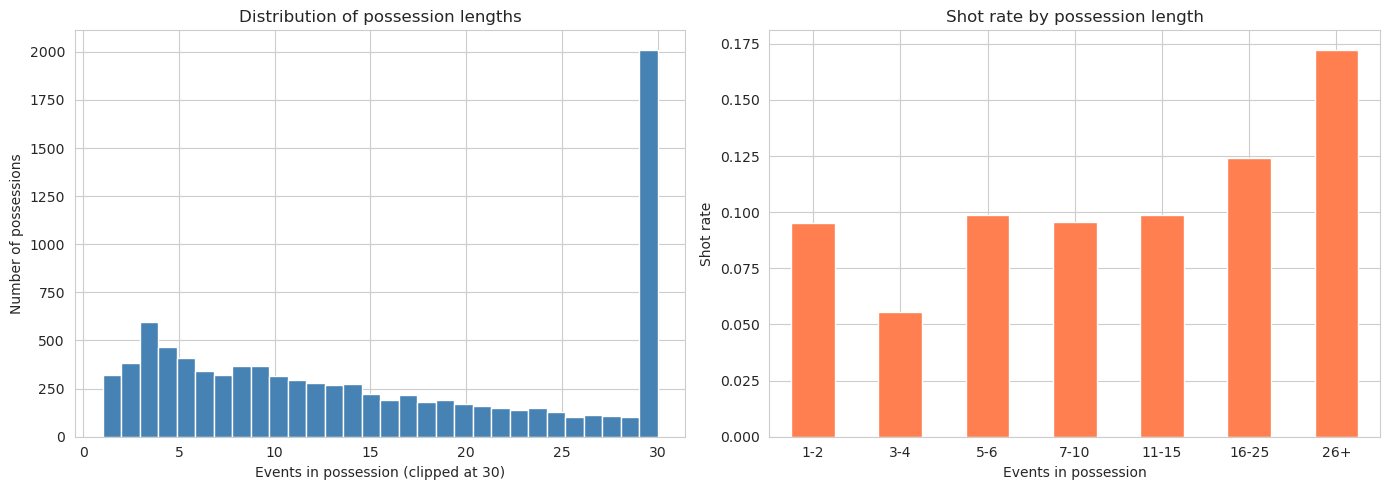

In [10]:
poss_length = df.groupby('poss_key').size()
print(poss_length.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of possession lengths
axes[0].hist(poss_length.clip(upper=30), bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Events in possession (clipped at 30)')
axes[0].set_ylabel('Number of possessions')
axes[0].set_title('Distribution of possession lengths')

# Shot rate by possession length
length_and_shot = pd.DataFrame({
    'length': poss_length,
    'shot': poss_labels
})
length_and_shot['length_bin'] = pd.cut(length_and_shot['length'],
                                        bins=[0, 2, 4, 6, 10, 15, 25, 100],
                                        labels=['1-2', '3-4', '5-6', '7-10', '11-15', '16-25', '26+'])
shot_by_length = length_and_shot.groupby('length_bin')['shot'].mean()
shot_by_length.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_ylabel('Shot rate')
axes[1].set_xlabel('Events in possession')
axes[1].set_title('Shot rate by possession length')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**What to notice**: Most possessions are short. But **longer possessions have a much higher shot rate** — because sustained possession usually means you've got into the final third. This is already a strong feature candidate.

**Suggested filter for your final dataset**: drop possessions with fewer than 3 events. They're usually trivial (goal kick out of play, immediate turnover) and add noise.

## 9. Deep dive: the `freeze_frame` column

This is the **most important column in the dataset**. Let's see what's actually in it.

The `freeze_frame` column stores, for each event, a list of all players who were visible on camera at that moment, with:
- Their `(x, y)` location on the pitch
- Whether they're a **teammate** of the player performing the event
- Whether they're the **goalkeeper**
- Whether they're the **actor** (the player doing the event)

**Important**: Not every event has a freeze frame — only events where StatsBomb captured 360 data. We'll check coverage below.

In [11]:
# First: how often is freeze_frame populated?
ff_col = 'freeze_frame' if 'freeze_frame' in df.columns else 'shot_freeze_frame'
print(f"Using column: {ff_col}")

ff_non_null = df[ff_col].notna().sum()
print(f"\nEvents with a freeze frame: {ff_non_null:,} / {len(df):,} ({ff_non_null/len(df):.1%})")

# By event type
print("\nFreeze frame coverage by event type:")
coverage = df.groupby('type')[ff_col].apply(lambda x: x.notna().mean()).sort_values(ascending=False)
print(coverage.head(15))

Using column: freeze_frame

Events with a freeze frame: 162,466 / 186,919 (86.9%)

Freeze frame coverage by event type:
type
Shot              0.966612
Interception      0.930876
Clearance         0.920418
Carry             0.918032
Ball Receipt*     0.897981
Ball Recovery     0.896249
Offside           0.894737
Block             0.883830
Pressure          0.877776
Duel              0.867681
Dispossessed      0.855566
Foul Committed    0.854035
Foul Won          0.851252
Dribbled Past     0.849704
50/50             0.848837
Name: freeze_frame, dtype: float64


**What to notice**: Freeze-frame coverage varies by event type. Some event types (e.g. shots, passes) are well-covered; others (e.g. substitutions, card events) won't have them, which makes sense — there's no meaningful "position snapshot" for an off-ball administrative event.

## 10. What's inside a single freeze frame?

Let's look at one concrete example.

In [12]:
# Find an event that has a freeze frame
sample_event = df[df[ff_col].notna()].iloc[100]

print(f"Event type: {sample_event['type']}")
print(f"Team:       {sample_event['possession_team']}")
print(f"Ball location: {sample_event.get('location', 'N/A')}")
print()
print("Freeze frame (raw):")
print(sample_event[ff_col][:500] + "...")  # first 500 chars

# Parse it
ff_raw = sample_event[ff_col]
if isinstance(ff_raw, str):
    ff_parsed = ast.literal_eval(ff_raw)
else:
    ff_parsed = ff_raw

print(f"\n\nNumber of players visible in this freeze frame: {len(ff_parsed)}")
print(f"\nFirst player entry:")
print(ff_parsed[0])
print(f"\nAll keys in a player entry: {list(ff_parsed[0].keys())}")

Event type: Pass
Team:       Argentina
Ball location: [62.0, 61.3]

Freeze frame (raw):
[{'teammate': True, 'actor': False, 'keeper': False, 'location': [61.05295620397938, 61.442216205208915]}, {'teammate': False, 'actor': False, 'keeper': False, 'location': [61.96943866856765, 60.44529106332732]}, {'teammate': True, 'actor': True, 'keeper': False, 'location': [62.0, 61.29999923706055]}, {'teammate': True, 'actor': False, 'keeper': False, 'location': [64.00018121797464, 28.25318873608586]}, {'teammate': False, 'actor': False, 'keeper': False, 'location': [68.4497973827237, 37.3056...


Number of players visible in this freeze frame: 15

First player entry:
{'teammate': True, 'actor': False, 'keeper': False, 'location': [61.05295620397938, 61.442216205208915]}

All keys in a player entry: ['teammate', 'actor', 'keeper', 'location']


**What to notice**:
- Each freeze frame is a **list of dicts**, one dict per visible player.
- Each dict has `teammate` (True if same team as the event's actor), `actor` (True if this player performed the event), and usually `keeper` (True if goalkeeper).
- Locations are `[x, y]` on a 120×80 pitch.
- The **number of players varies** (typically 8–20, not always 22) because it depends on who was in the camera's field of view.

## 11. Visualising a freeze frame on a pitch

This is the "aha!" cell. Seeing it on a pitch makes the data click.

In [13]:
def parse_freeze_frame(ff):
    """Parse a freeze frame string/list into a DataFrame."""
    if pd.isna(ff):
        return None
    if isinstance(ff, str):
        try:
            ff = ast.literal_eval(ff)
        except Exception:
            return None
    rows = []
    for p in ff:
        loc = p.get('location', [None, None])
        rows.append({
            'x': loc[0] if loc else None,
            'y': loc[1] if loc else None,
            'teammate': p.get('teammate', False),
            'keeper': p.get('keeper', False),
            'actor': p.get('actor', False),
        })
    return pd.DataFrame(rows)


def plot_freeze_frame(event_row, ff_column='freeze_frame', title=None):
    """Plot the freeze frame of one event on a pitch."""
    frame_df = parse_freeze_frame(event_row[ff_column])
    if frame_df is None:
        print("No freeze frame for this event.")
        return
    
    ball_loc = event_row.get('location')
    if isinstance(ball_loc, str):
        ball_loc = ast.literal_eval(ball_loc)
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#f4f4f4', line_color='#333')
    fig, ax = pitch.draw(figsize=(12, 7))
    
    # Teammates (blue)
    tm = frame_df[frame_df['teammate'] & ~frame_df['actor']]
    pitch.scatter(tm['x'], tm['y'], s=180, c='#1f77b4', ec='white', lw=1.5,
                  label=f'Teammates ({len(tm)})', ax=ax, zorder=3)
    # Opponents (red), excluding keeper
    opp = frame_df[~frame_df['teammate'] & ~frame_df['keeper']]
    pitch.scatter(opp['x'], opp['y'], s=180, c='#d62728', ec='white', lw=1.5,
                  label=f'Opponents ({len(opp)})', ax=ax, zorder=3)
    # Goalkeeper
    gk = frame_df[frame_df['keeper']]
    if len(gk):
        pitch.scatter(gk['x'], gk['y'], s=220, c='gold', ec='black', lw=1.5,
                      label='Goalkeeper', marker='s', ax=ax, zorder=4)
    # Actor (player on the ball)
    actor = frame_df[frame_df['actor']]
    if len(actor):
        pitch.scatter(actor['x'], actor['y'], s=300, c='#2ca02c', ec='black', lw=2,
                      label='Actor', marker='*', ax=ax, zorder=5)
    # Ball
    if ball_loc and ball_loc[0] is not None:
        pitch.scatter([ball_loc[0]], [ball_loc[1]], s=120, c='black', ec='white',
                      marker='o', label='Ball', ax=ax, zorder=6)
    
    if title:
        ax.set_title(title, fontsize=13)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    plt.tight_layout()
    plt.show()


if MPLSOCCER:
    # Pick a freeze frame that's in the attacking third (interesting)
    candidates = df[df[ff_col].notna() & df['location'].notna()].copy()
    candidates['loc_parsed'] = candidates['location'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    candidates['x_coord'] = candidates['loc_parsed'].apply(lambda l: l[0] if l else None)
    
    attacking = candidates[(candidates['x_coord'] > 80) & (candidates['type'] == 'Pass')]
    sample = attacking.iloc[0]
    plot_freeze_frame(sample, ff_column=ff_col,
                      title=f"Example freeze frame: {sample['type']} by {sample['possession_team']} "
                            f"(ball at x={sample['x_coord']:.1f})")

**What to notice**:
- The pitch is 120 × 80. The attacking team always goes **left to right**, attacking the goal at x = 120 (StatsBomb normalizes this).
- You can literally count defenders between ball and goal, measure distances to the nearest defender, see where space is.
- **This is where your spatial features come from** — everything you compute for the model should be measurable from this picture.

## 12. Compare: possession that ended in a shot vs one that didn't

Let's pick two possessions and compare the last event of each — to see visually what "high danger" vs "low danger" looks like.

In [14]:
if MPLSOCCER:
    # Pick one possession that ended in a shot, one that didn't
    # Both in attacking third, with freeze frames
    def get_sample_possession(ended_in_shot: bool):
        mask = (df['possession_ends_in_shot'] == int(ended_in_shot)) & df[ff_col].notna()
        candidates = df[mask].copy()
        candidates['loc_parsed'] = candidates['location'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        candidates['x_coord'] = candidates['loc_parsed'].apply(
            lambda l: l[0] if l and l[0] else 0)
        # Last event in the possession (before the shot, for shot possessions)
        if ended_in_shot:
            candidates = candidates[candidates['type'] != 'Shot']
        candidates = candidates[candidates['x_coord'] > 70]  # attacking third-ish
        if len(candidates):
            return candidates.iloc[0]
        return None

    shot_event = get_sample_possession(True)
    no_shot_event = get_sample_possession(False)

    if shot_event is not None:
        plot_freeze_frame(shot_event, ff_column=ff_col,
                          title=f"Possession that ENDED IN A SHOT — {shot_event['type']}, "
                                f"{shot_event['possession_team']}")
    if no_shot_event is not None:
        plot_freeze_frame(no_shot_event, ff_column=ff_col,
                          title=f"Possession that DID NOT end in a shot — {no_shot_event['type']}, "
                                f"{no_shot_event['possession_team']}")

**What to notice**: Look at defensive structure. Shot-ending possessions often have:
- Fewer defenders between ball and goal
- More space around the ball carrier
- The defensive line pushed higher up
- Attackers making runs behind the line

The non-shot example usually has the opposite. These visual patterns are your feature intuition.

## 13. Where do events happen? (The coordinate system)

Let's build a heatmap of where events happen, just to make sure coordinates are sane and we understand the pitch.

In [15]:
if MPLSOCCER:
    # Parse locations
    df_loc = df[df['location'].notna()].copy()
    df_loc['loc_parsed'] = df_loc['location'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df_loc['x'] = df_loc['loc_parsed'].apply(lambda l: l[0] if l else None)
    df_loc['y'] = df_loc['loc_parsed'].apply(lambda l: l[1] if l else None)
    df_loc = df_loc.dropna(subset=['x', 'y'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap of all events
    pitch = Pitch(pitch_type='statsbomb', line_color='black')
    pitch.draw(ax=axes[0])
    pitch.kdeplot(df_loc.sample(min(20000, len(df_loc)))['x'],
                  df_loc.sample(min(20000, len(df_loc)))['y'],
                  ax=axes[0], fill=True, levels=50, thresh=0.05, cmap='Reds')
    axes[0].set_title('All events — heatmap', fontsize=12)

    # Heatmap of shots only
    shots = df_loc[df_loc['type'] == 'Shot']
    pitch2 = Pitch(pitch_type='statsbomb', line_color='black')
    pitch2.draw(ax=axes[1])
    pitch2.kdeplot(shots['x'], shots['y'],
                   ax=axes[1], fill=True, levels=50, thresh=0.05, cmap='Blues')
    axes[1].set_title(f'Shots only — heatmap (n={len(shots):,})', fontsize=12)

    plt.tight_layout()
    plt.show()

**What to notice**:
- All events are spread across the pitch, with concentration in central and wide attacking zones.
- Shots cluster tightly in and around the penalty area — as expected.
- **Remember**: StatsBomb normalizes coordinates so the possessing team always attacks left→right. You don't need to worry about teams switching halves — it's already handled.

## 14. Missing data — what's populated where?

Understanding which columns have NaNs (and why) prevents silent bugs later.

In [16]:
# Focus on the columns we actually care about for features
key_cols = ['location', 'pass_length', 'pass_end_location', 'under_pressure',
            'pass_outcome', 'shot_outcome', 'shot_statsbomb_xg',
            ff_col, 'possession_team']
key_cols = [c for c in key_cols if c in df.columns]

missing = pd.DataFrame({
    'column': key_cols,
    'missing_count': [df[c].isna().sum() for c in key_cols],
    'missing_pct': [df[c].isna().mean() * 100 for c in key_cols],
    'dtype': [df[c].dtype for c in key_cols]
}).sort_values('missing_pct', ascending=False)

print(missing.to_string(index=False))

           column  missing_count  missing_pct   dtype
shot_statsbomb_xg         185691    99.343031 float64
     shot_outcome         185691    99.343031  object
     pass_outcome         177103    94.748527  object
   under_pressure         155801    83.352147  object
      pass_length         132343    70.802326 float64
pass_end_location         132343    70.802326  object
     freeze_frame          24453    13.082137  object
         location           1706     0.912695  object
  possession_team              0     0.000000  object


**What to notice**: A lot of "missingness" here is **expected** — e.g., `shot_outcome` is only filled for Shot events. The columns to watch carefully are `location` and `freeze_frame`: those are your feature sources, and if they're null you can't compute spatial features for that event.

**Rule of thumb**: when building features, filter to events that have both `location` AND `freeze_frame` before computing spatial features. Aggregate what's available to the possession level.

## 15. Quick preview: do simple features already separate the classes?

Before we build the real feature pipeline, let's confirm that at least *some* signal exists with easy features.

In [17]:
# Build a tiny feature set from just event data (no freeze_frame yet)
# Aggregate each possession

# Safe parser — handles NaN, strings, and already-parsed lists
def parse_loc(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return None
    if isinstance(x, (list, tuple)):
        return x
    return None  # NaN, None, anything else

df['loc_parsed'] = df['location'].apply(parse_loc)
df['ball_x'] = df['loc_parsed'].apply(
    lambda l: l[0] if isinstance(l, (list, tuple)) and len(l) >= 2 else None)
df['ball_y'] = df['loc_parsed'].apply(
    lambda l: l[1] if isinstance(l, (list, tuple)) and len(l) >= 2 else None)

print(f"Events with ball location:    {df['ball_x'].notna().sum():,} / {len(df):,}")
print(f"Events missing ball location: {df['ball_x'].isna().sum():,}")

# Exclude shot events when computing features (prevents leakage)
df_no_shots = df[df['type'] != 'Shot']

simple_features = df_no_shots.groupby('poss_key').agg(
    n_events=('type', 'size'),
    n_passes=('type', lambda x: (x == 'Pass').sum()),
    max_x_reached=('ball_x', 'max'),
    mean_x=('ball_x', 'mean'),
    under_pressure_count=('under_pressure', lambda x: (x == True).sum()),
).reset_index()

# Join the label back
simple_features['ends_in_shot'] = simple_features['poss_key'].map(poss_labels)

# Drop possessions with fewer than 3 events (trivial)
simple_features = simple_features[simple_features['n_events'] >= 3]

print(f"\nPossessions kept after filter (≥3 events): {len(simple_features):,}")
print(f"Shot-ending possessions:     {simple_features['ends_in_shot'].sum():,} "
      f"({simple_features['ends_in_shot'].mean():.1%})")

print("\n=== Means by class ===")
print(simple_features.groupby('ends_in_shot')[
    ['n_events', 'n_passes', 'max_x_reached', 'mean_x', 'under_pressure_count']
].mean().T)

Events with ball location:    185,213 / 186,919
Events missing ball location: 1,706

Possessions kept after filter (≥3 events): 8,620
Shot-ending possessions:     1,018 (11.8%)

=== Means by class ===
ends_in_shot                  0           1
n_events              20.542226   27.977407
n_passes               6.087345    7.710216
max_x_reached         91.263528  108.214931
mean_x                55.282690   63.668992
under_pressure_count   3.488819    4.249509


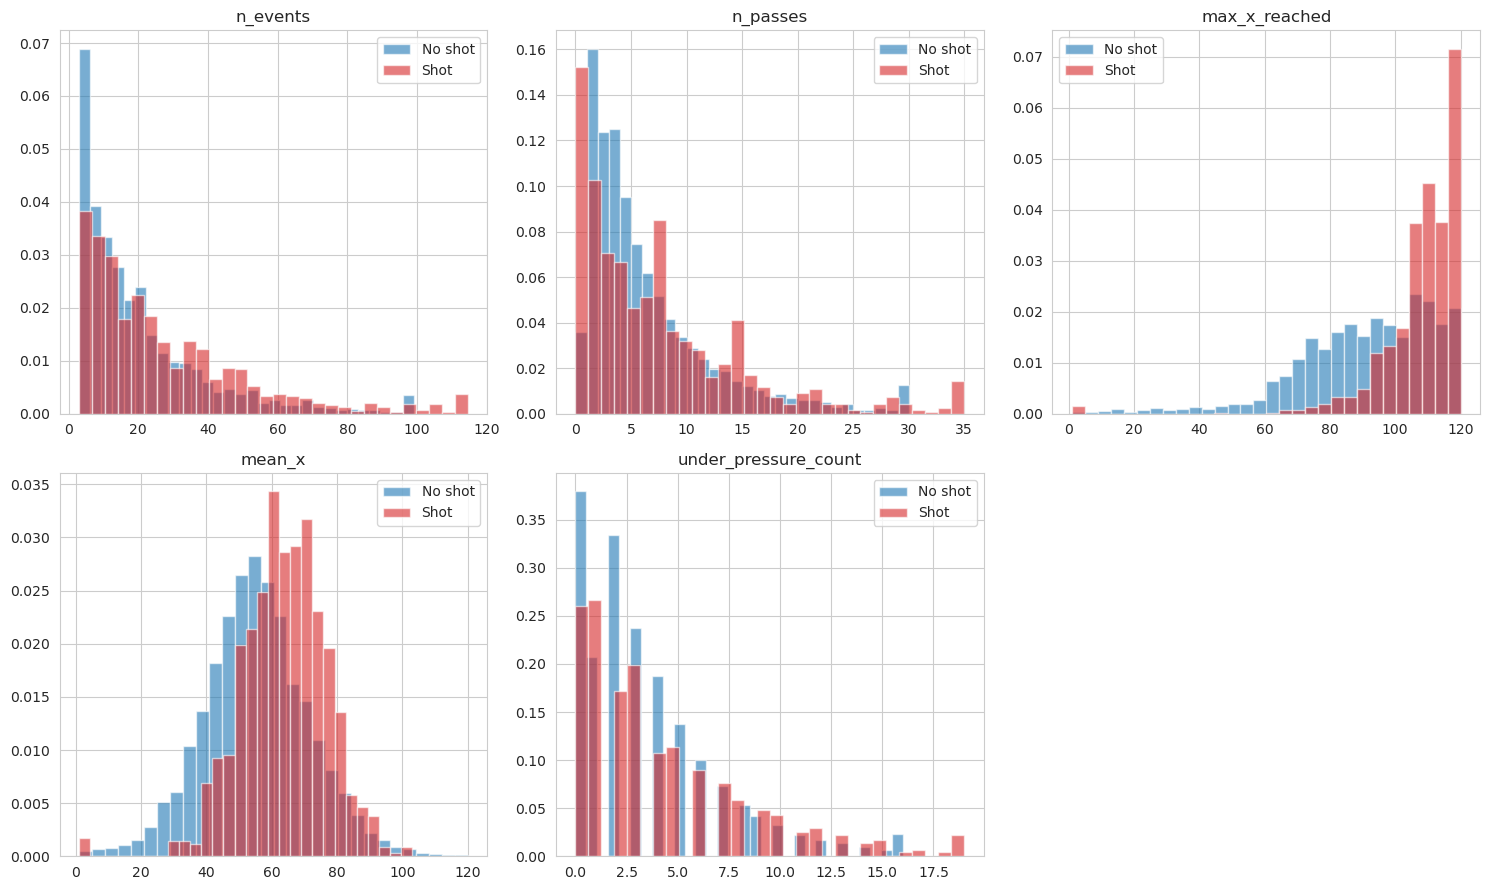

In [18]:
# Visualise the separation
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
feats = ['n_events', 'n_passes', 'max_x_reached', 'mean_x', 'under_pressure_count']

for ax, feat in zip(axes.ravel(), feats):
    for label, color, name in [(0, '#1f77b4', 'No shot'), (1, '#d62728', 'Shot')]:
        data = simple_features[simple_features['ends_in_shot'] == label][feat].dropna()
        # Clip for readability
        if feat in ['n_events', 'n_passes', 'under_pressure_count']:
            data = data.clip(upper=data.quantile(0.99))
        ax.hist(data, bins=30, alpha=0.6, label=name, color=color, density=True)
    ax.set_title(feat)
    ax.legend()

# Remove unused axis
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

**What to notice**: `max_x_reached` should show the clearest separation — shot-ending possessions push much further up the pitch. `n_events` and `n_passes` also separate decently.

These are the **baseline features**. Your freeze-frame features need to add on top of these — the value-add of 360 data is capturing *context* (defenders, space) that these simple metrics miss.

## 17. Shot rate by `play_pattern` — the easiest high-signal feature

StatsBomb has already labelled **how each possession started** in the `play_pattern` column. Values include:

- `Regular Play` — the default, in-game flow
- `From Counter` — fast attack after winning the ball
- `From Corner`, `From Free Kick`, `From Throw In`, `From Kick Off`
- `From Goal Kick`, `From Keeper`
- `Other`

Different start types have *very* different shot rates. Counter-attacks and set pieces convert at a much higher rate than regular possession. If we didn't use this feature, we'd be making the model do extra work to re-learn a signal that's already sitting right there in one column.

**This single feature is probably more predictive than any one spatial feature.**

                n_possessions  shot_rate
play_pattern                            
From Corner               472      0.347
Other                     183      0.322
From Counter              153      0.281
From Free Kick           1449      0.144
From Throw In            2090      0.105
Regular Play             3676      0.088
From Goal Kick            799      0.074
From Keeper               276      0.051
From Kick Off             241      0.041


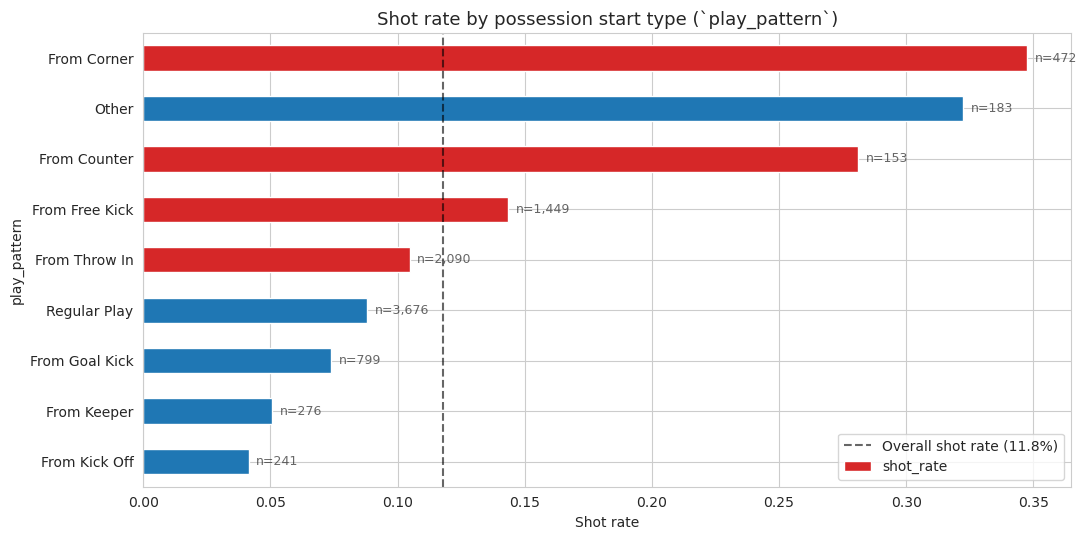

In [19]:
# Shot rate by play_pattern
pp_data = (df.groupby('poss_key')
             .agg(play_pattern=('play_pattern', 'first'),
                  ends_in_shot=('possession_ends_in_shot', 'first'))
             .groupby('play_pattern')
             .agg(n_possessions=('ends_in_shot', 'count'),
                  shot_rate=('ends_in_shot', 'mean'))
             .sort_values('shot_rate', ascending=False))

print(pp_data.round(3))

overall_rate = poss_labels.mean()

fig, ax = plt.subplots(figsize=(11, 5.5))
# Colour high-signal patterns in red, others in blue
high_signal = {'From Counter', 'From Corner', 'From Free Kick', 'From Throw In'}
colors = ['#d62728' if p in high_signal else '#1f77b4' for p in pp_data.index]

pp_data['shot_rate'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(overall_rate, color='black', linestyle='--', alpha=0.6,
           label=f'Overall shot rate ({overall_rate:.1%})')
ax.set_xlabel('Shot rate')
ax.set_title('Shot rate by possession start type (`play_pattern`)', fontsize=13)
ax.invert_yaxis()
ax.legend(loc='lower right')

# Annotate sample size next to each bar
for i, (idx, row) in enumerate(pp_data.iterrows()):
    ax.text(row['shot_rate'] + 0.003, i, f"n={int(row['n_possessions']):,}",
            va='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

**What to notice**:

- **Counter-attacks convert at ~2–3× the overall rate.** That makes football sense — defences are unsettled, numbers are even or favourable, space is wide open.
- **Set pieces** (corners, free kicks) also over-index, but for a different reason: proximity to goal and designed plays.
- **"From Goal Kick" and "From Keeper"** are the lowest-converting — possessions that start deep in your own end rarely reach a shot before something breaks them up.
- **"Regular Play"** sits close to the overall average by construction — it's the largest bucket.

**For your deck**: this chart deserves to be one of your 5+ required visuals. It's interpretable in 3 seconds and tells the coach-facing story immediately: "the *kind* of possession matters a lot, and here's how much."

**For your model**: one-hot encode `play_pattern` and include it as features. With this plus the spatial features from freeze frames, you're covering both the "how it started" and "what's happening right now" dimensions of possession quality.

## 18. A famous moment — freeze frame from the 2022 World Cup final

Every generic "random pass at x=85" freeze-frame plot is forgettable. A freeze frame of **a moment the audience recognises** is instantly engaging, and demonstrates that your pipeline works on real, meaningful plays — not just synthetic examples.

Let's find the Argentina–France final and plot the freeze frame of one of its goals.

In [20]:
# Find the Argentina vs France match
arg_matches = set(df.loc[df['possession_team'] == 'Argentina', MATCH_COL].unique())
fra_matches = set(df.loc[df['possession_team'] == 'France', MATCH_COL].unique())
final_candidates = arg_matches & fra_matches

print(f"Matches where both Argentina and France played: {len(final_candidates)}")
# In WC2022 knockouts they only met once — the final
final_match_id = list(final_candidates)[0]
print(f"Using match_id = {final_match_id}")

# All shots in the final
final_shots = df[(df[MATCH_COL] == final_match_id) & (df['type'] == 'Shot')].copy()
print(f"\nTotal shots in the final: {len(final_shots)}")

# Goals only
goals = final_shots[final_shots['shot_outcome'] == 'Goal'].sort_values(['period', 'minute'])
print(f"Goals scored in the final: {len(goals)}")
print()
print(goals[['minute', 'second', 'period', 'possession_team', 'player',
             'shot_statsbomb_xg']].to_string(index=False))

Matches where both Argentina and France played: 1
Using match_id = 3869685

Total shots in the final: 38
Goals scored in the final: 12

 minute  second  period possession_team                          player  shot_statsbomb_xg
     22      24       1       Argentina  Lionel Andrés Messi Cuccittini           0.783500
     35      22       1       Argentina Ángel Fabián Di María Hernández           0.303409
     79      24       2          France            Kylian Mbappé Lottin           0.783500
     80      59       2          France            Kylian Mbappé Lottin           0.101703
    107      58       4       Argentina  Lionel Andrés Messi Cuccittini           0.488404
    117       5       4          France            Kylian Mbappé Lottin           0.783500
    120      13       5          France            Kylian Mbappé Lottin           0.783500
    121       2       5       Argentina  Lionel Andrés Messi Cuccittini           0.783500
    122      27       5       Argentina     P

In [21]:
# Plot the freeze frame of the most iconic goal: Di Maria's 36'
# (Second Argentina goal, from the Messi-Mac Allister-Alvarez-Di Maria counter)
# If that one's freeze_frame is missing, fall back to any other goal with a frame.

if MPLSOCCER:
    # Prefer Di Maria's goal, otherwise any goal with a freeze frame
    di_maria_goal = goals[goals['player'].str.contains('María|Maria', na=False, regex=True)]
    if len(di_maria_goal) and pd.notna(di_maria_goal.iloc[0]['freeze_frame']):
        chosen = di_maria_goal.iloc[0]
    else:
        # Fallback: first goal with a freeze frame
        with_ff = goals[goals['freeze_frame'].notna()]
        chosen = with_ff.iloc[0] if len(with_ff) else goals.iloc[0]

    title = (f"{chosen['player']} — {chosen['possession_team']} — "
             f"{int(chosen['minute'])}'{int(chosen['second']):02d} "
             f"(xG: {chosen['shot_statsbomb_xg']:.2f})")

    plot_freeze_frame(chosen, ff_column='freeze_frame', title=title)

**What to notice**:

- You can literally see the defensive shape at the moment of the shot: where France's back line is, who's marking, who's not.
- The `actor` (star) is the shooter. The ball is the black dot. Teammates blue, opponents red, keeper gold.
- **For the deck**: this goes on a slide titled something like *"What 360 data lets us see"* — a recognisable moment that makes the capability concrete.

**One thing to be honest about in the presentation**: not every frame is this crisp. Some frames show only 8 players because the rest were off-camera. You'll want to address that limitation with the `visible_area` size feature in the modelling phase — but as a demo of what the data *can* do, a World Cup final goal freeze frame is hard to beat.

---

# Part B — Modeling

We now build the full modeling pipeline. Feature design is grounded in how pro analysts actually approach this:

- **StatsBomb OBV / VAEP (Decroos et al.)**: pitch location + action context + pressure, modelled with XGBoost
- **Line-breaking passes (StatsBomb 360)**: completed passes that advance ≥10% closer to goal AND intersect defenders OR end behind the defensive line
- **Packing**: number of opponents bypassed by ball progression
- **Ball receipts in space (StatsBomb 360)**: distance-to-nearest-defender bucketed at 0–2, 2–5, 5–10, 10+ yards

## 19. Modeling setup

We import the modeling-specific libraries. `pandas`, `numpy`, `matplotlib` are already loaded from Part A.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import xgboost as xgb

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("shap not installed — install with `pip install shap` for SHAP plots.")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Modeling libraries loaded.")

Modeling libraries loaded.


## 20. Modeling parsers + possession key

The EDA section already loaded the parsers and defined `poss_key`. We re-declare a couple of modeling-specific helpers here so this part of the notebook is self-contained.

In [23]:
# NaN-safe list parser used throughout modeling
def parse_list(x):
    """Parse a value that might be a string-encoded list, an actual list, or NaN."""
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return None
    if isinstance(x, (list, tuple)):
        return x
    return None


def loc_xy(loc_parsed):
    """Return (x, y) from a parsed location, or (NaN, NaN) if invalid."""
    if isinstance(loc_parsed, (list, tuple)) and len(loc_parsed) >= 2:
        try:
            return float(loc_parsed[0]), float(loc_parsed[1])
        except (ValueError, TypeError):
            return np.nan, np.nan
    return np.nan, np.nan


# Make sure we have all the columns modeling needs
# (ball_x/ball_y should already exist from EDA Section 15; re-create if missing)
if 'ball_x' not in df.columns:
    df['loc_parsed'] = df['location'].apply(parse_list)
    df['ball_x'] = df['loc_parsed'].apply(lambda l: loc_xy(l)[0])
    df['ball_y'] = df['loc_parsed'].apply(lambda l: loc_xy(l)[1])

# Pass end locations (needed for line-breaking passes + packing)
df['pass_end_parsed'] = df['pass_end_location'].apply(parse_list)
df['pass_end_x'] = df['pass_end_parsed'].apply(lambda l: loc_xy(l)[0])
df['pass_end_y'] = df['pass_end_parsed'].apply(lambda l: loc_xy(l)[1])

# Carry end locations
df['carry_end_parsed'] = df['carry_end_location'].apply(parse_list)
df['carry_end_x'] = df['carry_end_parsed'].apply(lambda l: loc_xy(l)[0])
df['carry_end_y'] = df['carry_end_parsed'].apply(lambda l: loc_xy(l)[1])

# Make sure poss_key + ends_in_shot are set (they should be from EDA)
if 'poss_key' not in df.columns:
    df['poss_key'] = df[MATCH_COL].astype(str) + '_' + df['possession'].astype(str)
if 'ends_in_shot' not in df.columns or 'possession_ends_in_shot' not in df.columns:
    shot_poss = df.loc[df['type'] == 'Shot', 'poss_key'].unique()
    df['ends_in_shot'] = df['poss_key'].isin(shot_poss).astype(int)
    df['possession_ends_in_shot'] = df['ends_in_shot']

# Standardize a 'match_id' column name for modeling
if 'match_id' not in df.columns:
    df['match_id'] = df[MATCH_COL]

print(f"Possessions: {df['poss_key'].nunique():,}")
print(f"Shot rate: {df.groupby('poss_key')['ends_in_shot'].first().mean():.1%}")
print(f"df ready for modeling with {df.shape[1]} columns.")

Possessions: 9,339
Shot rate: 11.8%
df ready for modeling with 132 columns.


## 21. ⚠️ Critical leakage fix — truncate at first shot

**The bug**: in the previous version, we dropped `type == 'Shot'` rows before aggregating features. But for shot-ending possessions, the event *right after the shot* (the clearance, the keeper save, the opponent's ball recovery) is still in the data. The ball is now on the opposite end of the pitch. When we compute "end_ball_x" or "last position" features, we're picking up the aftermath, which is a dead giveaway that a shot happened.

**Evidence that this was a real problem**: with the old code, `forward_progression` had a **negative** correlation with the shot label — because shot-ending possessions appeared to "end" with the ball far from goal (where the keeper cleared it to). Totally backwards from reality.

**The fix**: for each possession, find the index of the first Shot event. Keep only events that happened **strictly before** that shot. Non-shot possessions are unaffected.

In [24]:
# Sort chronologically within matches so `index` ordering is meaningful
df = df.sort_values(['match_id', 'index']).reset_index(drop=True)

# For each possession, find the index of the FIRST shot event (if any)
first_shot_idx = (df[df['type'] == 'Shot']
                  .groupby('poss_key')['index']
                  .min()
                  .rename('first_shot_index'))

n_with_shot = len(first_shot_idx)
print(f"Possessions containing at least one shot: {n_with_shot:,}")

# Attach this to df, then keep only events that happen BEFORE the first shot
df_truncated = df.merge(first_shot_idx, on='poss_key', how='left')

# For non-shot possessions, first_shot_index is NaN, so keep everything.
# For shot possessions, keep only events with index < first_shot_index.
keep_mask = df_truncated['first_shot_index'].isna() | (df_truncated['index'] < df_truncated['first_shot_index'])
df_pre_shot = df_truncated[keep_mask].copy()

print(f"\nEvents before truncation:  {len(df):,}")
print(f"Events after truncation:   {len(df_pre_shot):,}  ({len(df_pre_shot)/len(df):.1%} retained)")

# Sanity: no Shot events should remain in df_pre_shot
assert (df_pre_shot['type'] == 'Shot').sum() == 0, \
    "Shot events still present after truncation — this is a bug!"
print(f"\n✓ Zero Shot events remain in truncated data (leakage prevented)")
print(f"✓ Use `df_pre_shot` for all downstream feature engineering")

Possessions containing at least one shot: 1,100

Events before truncation:  186,919
Events after truncation:   180,134  (96.4% retained)

✓ Zero Shot events remain in truncated data (leakage prevented)
✓ Use `df_pre_shot` for all downstream feature engineering


## 22. Parse freeze frames (cached)

Freeze frames are expensive to parse; we do it once and cache to disk. Subsequent runs reload instantly.

In [25]:
import os

CACHE_PATH = '/tmp/freeze_frames_long.parquet'

if os.path.exists(CACHE_PATH):
    print(f"Loading cached freeze frames from {CACHE_PATH}")
    ff_long = pd.read_parquet(CACHE_PATH)
else:
    print("Parsing freeze frames (one-time cost)...")
    rows = []
    df_with_ff = df[df['freeze_frame'].notna()].copy()
    for idx, row in df_with_ff.iterrows():
        ff = parse_list(row['freeze_frame'])
        if ff is None:
            continue
        event_id = row['id']
        for p in ff:
            loc = p.get('location', [None, None])
            try:
                x = float(loc[0]) if loc and loc[0] is not None else np.nan
                y = float(loc[1]) if loc and loc[1] is not None else np.nan
            except (ValueError, TypeError, IndexError):
                x, y = np.nan, np.nan
            rows.append({
                'event_id': event_id,
                'x': x,
                'y': y,
                'teammate': bool(p.get('teammate', False)),
                'keeper': bool(p.get('keeper', False)),
                'actor': bool(p.get('actor', False)),
            })
    ff_long = pd.DataFrame(rows).dropna(subset=['x', 'y'])
    try:
        ff_long.to_parquet(CACHE_PATH)
    except Exception as e:
        print(f"(Could not cache: {e})")

print(f"Parsed freeze-frame player rows: {len(ff_long):,}")
print(f"Events with ≥1 parsed player: {ff_long['event_id'].nunique():,}")

Loading cached freeze frames from /tmp/freeze_frames_long.parquet
Parsed freeze-frame player rows: 2,455,735
Events with ≥1 parsed player: 162,466


## 23. Event-level spatial features from freeze frames

For every event with a freeze frame + ball location, compute 11 spatial features:

| Feature | Why it matters |
|---|---|
| `dist_to_nearest_def` | Ball-receipts-in-space base metric (StatsBomb) |
| `n_def_within_2m`, `_5m`, `_10m` | Distance-bucketed pressure (StatsBomb's own cuts) |
| `n_def_between_ball_and_goal` | Packing concept — defenders in the way |
| `def_line_height` | Mean x of back 4 opponents — high line = danger behind |
| `def_block_compactness` | Std of opponent y positions — narrow = hard to penetrate |
| `space_around_actor` | Nearest opponent to the player on the ball |
| `n_teammates_ahead` | Forward passing options |
| `keeper_depth` | GK off their line = space behind |
| `n_players_visible` | Data-quality indicator |

In [26]:
# Event-level: ball location keyed by event_id
event_ball = df.set_index('id')[['ball_x', 'ball_y']]

# Split freeze-frame rows into teammate/opponent/keeper views
tm = ff_long[ff_long['teammate']]
opp = ff_long[~ff_long['teammate'] & ~ff_long['keeper']]
gk = ff_long[ff_long['keeper']]
actor = ff_long[ff_long['actor']]

# For every event with a freeze frame, compute the spatial features
event_ids = ff_long['event_id'].unique()

# ---- pre-aggregations ----

# Per-event opponent locations as lists (for fast vectorized ops per event)
opp_grouped = opp.groupby('event_id')[['x', 'y']].apply(lambda g: g.values).to_dict()
tm_grouped = tm.groupby('event_id')[['x', 'y']].apply(lambda g: g.values).to_dict()
gk_grouped = gk.groupby('event_id')[['x', 'y']].apply(lambda g: g.values).to_dict()
actor_grouped = actor.groupby('event_id')[['x', 'y']].apply(
    lambda g: g.values[0] if len(g) else np.array([np.nan, np.nan])).to_dict()
n_visible = ff_long.groupby('event_id').size().to_dict()


def _features_for_event(event_id):
    ball = event_ball.loc[event_id] if event_id in event_ball.index else None
    if ball is None or pd.isna(ball['ball_x']):
        return None

    bx, by = float(ball['ball_x']), float(ball['ball_y'])
    opps = opp_grouped.get(event_id, np.empty((0, 2)))
    tms = tm_grouped.get(event_id, np.empty((0, 2)))
    gks = gk_grouped.get(event_id, np.empty((0, 2)))
    act = actor_grouped.get(event_id, np.array([np.nan, np.nan]))

    out = {'event_id': event_id, 'n_players_visible': n_visible.get(event_id, 0)}

    # Opponent distances to ball
    if len(opps) > 0:
        d_opp_ball = np.sqrt((opps[:, 0] - bx) ** 2 + (opps[:, 1] - by) ** 2)
        out['dist_to_nearest_def'] = float(d_opp_ball.min())
        out['n_def_within_2m'] = int((d_opp_ball < 2).sum())
        out['n_def_within_5m'] = int((d_opp_ball < 5).sum())
        out['n_def_within_10m'] = int((d_opp_ball < 10).sum())
        # Packing: defenders between ball and goal (ball_x < def_x < 120)
        out['n_def_between_ball_and_goal'] = int(
            ((opps[:, 0] > bx) & (opps[:, 0] < 120)).sum())
        # Defensive line height: mean x of 4 deepest (lowest x) opponents
        sorted_x = np.sort(opps[:, 0])
        out['def_line_height'] = float(
            sorted_x[:4].mean() if len(sorted_x) >= 4 else sorted_x.mean())
        # Compactness: std of opponent y (pitch is 80 wide, smaller = narrower block)
        out['def_block_compactness'] = float(opps[:, 1].std()) if len(opps) > 1 else np.nan
    else:
        for k in ['dist_to_nearest_def', 'n_def_within_2m', 'n_def_within_5m',
                  'n_def_within_10m', 'n_def_between_ball_and_goal',
                  'def_line_height', 'def_block_compactness']:
            out[k] = np.nan

    # Space around the actor (player on the ball)
    if not np.isnan(act[0]) and len(opps) > 0:
        d_act = np.sqrt((opps[:, 0] - act[0]) ** 2 + (opps[:, 1] - act[1]) ** 2)
        out['space_around_actor'] = float(d_act.min())
    else:
        out['space_around_actor'] = np.nan

    # Teammates ahead of ball (x > ball_x)
    if len(tms) > 0:
        out['n_teammates_ahead'] = int((tms[:, 0] > bx).sum())
    else:
        out['n_teammates_ahead'] = 0

    # Keeper depth: GK distance from own goal (x=0 for own keeper? actually keeper
    # is on defending side, so attacking team has GK at high x → use distance from x=120)
    # In StatsBomb the attacking direction is always x→120, so the opposing keeper
    # sits near x=120. Keeper depth = how far OUT of the goal they are = 120 - gk_x.
    if len(gks) > 0:
        out['keeper_depth'] = float(120 - gks[0, 0])
    else:
        out['keeper_depth'] = np.nan

    return out


# Vectorize over events (keep it simple — ~200k events, runs in a minute or two)
print(f"Computing spatial features for {len(event_ids):,} events...")
feat_rows = []
for i, eid in enumerate(event_ids):
    feat = _features_for_event(eid)
    if feat is not None:
        feat_rows.append(feat)
    if (i + 1) % 25000 == 0:
        print(f"  {i+1:,} / {len(event_ids):,}")

event_features = pd.DataFrame(feat_rows).set_index('event_id')
print(f"\nEvent-level features: {event_features.shape}")
print(event_features.describe().round(2).T)

Computing spatial features for 162,466 events...
  25,000 / 162,466
  50,000 / 162,466
  75,000 / 162,466
  100,000 / 162,466
  125,000 / 162,466
  150,000 / 162,466

Event-level features: (162466, 11)
                                count   mean    std   min    25%     50%  \
n_players_visible            162466.0  15.12   3.60  1.00  13.00   16.00   
dist_to_nearest_def          162087.0   9.27  12.68  0.00   2.80    5.73   
n_def_within_2m              162087.0   0.17   0.39  0.00   0.00    0.00   
n_def_within_5m              162087.0   0.57   0.73  0.00   0.00    0.00   
n_def_within_10m             162087.0   1.38   1.27  0.00   0.00    1.00   
n_def_between_ball_and_goal  162087.0   5.32   2.68  0.00   3.00    5.00   
def_line_height              162087.0  58.75  24.83 -0.09  39.67   59.35   
def_block_compactness        160998.0  12.63   3.26  0.02  10.63   12.64   
space_around_actor           162087.0   6.64   5.48  0.00   2.43    4.99   
n_teammates_ahead            162466.0 

## 24. Line-breaking passes + packing

Two StatsBomb-published metrics, computed at the event level on Pass events:

- **Line-breaking pass**: completed pass that advances ≥10% closer to goal AND (ends behind the defensive line OR packs ≥2 defenders)
- **Packing**: number of opponents bypassed by ball's forward movement

In [27]:
def pass_features(row, opp_locs):
    """Compute line-breaking and packing features for one Pass event."""
    out = {'is_line_breaking': 0, 'n_defenders_packed': 0, 'pass_progression': 0.0}

    bx, by = row['ball_x'], row['ball_y']
    ex, ey = row['pass_end_x'], row['pass_end_y']
    if any(pd.isna(v) for v in [bx, by, ex, ey]):
        return out

    # Progression: how much closer to the 120-line did we get?
    start_dist = 120 - bx
    end_dist = 120 - ex
    if start_dist <= 0:
        return out
    progression_ratio = (start_dist - end_dist) / start_dist
    out['pass_progression'] = float(progression_ratio)

    # Only count as line-breaking if advances ≥10% closer to goal
    if progression_ratio < 0.10:
        return out

    if opp_locs is None or len(opp_locs) == 0:
        return out

    # Packing: count defenders whose x is between bx and ex (bypassed going forward)
    if ex > bx:
        packed_mask = (opp_locs[:, 0] > bx) & (opp_locs[:, 0] < ex)
        out['n_defenders_packed'] = int(packed_mask.sum())

    # Line-breaking criterion (simplified):
    # (a) the pass end is behind the 4 deepest opponents, i.e. ex > 4th-highest opp_x
    # OR (b) at least 2 opponents are packed (intersecting defensive pair)
    sorted_opp_x = np.sort(opp_locs[:, 0])[::-1]  # highest first
    if len(sorted_opp_x) >= 4:
        fourth_deepest = sorted_opp_x[3]  # 4th opponent closest to our goal-end
    elif len(sorted_opp_x):
        fourth_deepest = sorted_opp_x[-1]
    else:
        fourth_deepest = None

    behind_line = (fourth_deepest is not None) and (ex > fourth_deepest)
    packed_pair = out['n_defenders_packed'] >= 2

    if behind_line or packed_pair:
        out['is_line_breaking'] = 1

    return out


# Apply to passes only
passes = df[df['type'] == 'Pass'].copy()
print(f"Pass events: {len(passes):,}")

lb_feats = []
for idx, row in passes.iterrows():
    opps = opp_grouped.get(row['id'])
    feat = pass_features(row, opps)
    feat['event_id'] = row['id']
    lb_feats.append(feat)

pass_360_features = pd.DataFrame(lb_feats).set_index('event_id')

print(f"\nLine-breaking passes: {pass_360_features['is_line_breaking'].sum():,} "
      f"({pass_360_features['is_line_breaking'].mean():.1%} of passes)")
print(f"Mean defenders packed per pass: {pass_360_features['n_defenders_packed'].mean():.2f}")
print(f"Mean pass progression: {pass_360_features['pass_progression'].mean():.3f}")

Pass events: 54,576

Line-breaking passes: 17,427 (31.9% of passes)
Mean defenders packed per pass: 1.31
Mean pass progression: 0.054


## 25. Aggregate to possession level

Now we roll up event-level features to possession-level. We use `df_pre_shot` (truncated at first shot) instead of `df_no_shot` — this is the leakage fix from Section 21 taking effect.

**Aggregations**:
- Spatial features: `min`, `mean`, `max` per possession
- Line-breaking + packing: `sum` + `max`
- Event counts, progression, context flags

In [28]:
# Attach event-level features to the truncated df
df_feat = df_pre_shot.merge(event_features, left_on='id', right_index=True, how='left')
df_feat = df_feat.merge(pass_360_features, left_on='id', right_index=True, how='left')

# ALSO bring in full df for context features that are invariant across truncation
# (first-event info, play_pattern, team, period — these all come from the possession's start)
df_full = df.merge(event_features, left_on='id', right_index=True, how='left')

# Note: We use df_feat (the truncated view) for ALL feature aggregation
# We only use df_full for label + context (play_pattern, possession_team, etc.)

# ---- Spatial aggregations: min, mean, max ----
spatial_cols = [
    'dist_to_nearest_def', 'n_def_within_2m', 'n_def_within_5m', 'n_def_within_10m',
    'n_def_between_ball_and_goal', 'def_line_height', 'def_block_compactness',
    'space_around_actor', 'n_teammates_ahead', 'keeper_depth', 'n_players_visible'
]

spatial_agg = df_feat.groupby('poss_key')[spatial_cols].agg(['min', 'mean', 'max'])
spatial_agg.columns = [f"{c}_{s}" for c, s in spatial_agg.columns]

# ---- Line-breaking / packing aggregations: sum + max ----
lb_agg = df_feat.groupby('poss_key').agg(
    n_line_breaking_passes=('is_line_breaking', 'sum'),
    max_pass_progression=('pass_progression', 'max'),
    total_defenders_packed=('n_defenders_packed', 'sum'),
    max_defenders_packed=('n_defenders_packed', 'max'),
)

# ---- Event-count / progression features ----
basic_agg = df_feat.groupby('poss_key').agg(
    n_events=('type', 'size'),
    n_passes=('type', lambda x: (x == 'Pass').sum()),
    n_carries=('type', lambda x: (x == 'Carry').sum()),
    n_dribbles=('type', lambda x: (x == 'Dribble').sum()),
    max_ball_x=('ball_x', 'max'),
    mean_ball_x=('ball_x', 'mean'),
    start_ball_x=('ball_x', 'first'),
    end_ball_x=('ball_x', 'last'),
    times_under_pressure=('under_pressure', lambda x: x.fillna(False).astype(bool).sum()),
    any_counterpress=('counterpress', lambda x: x.fillna(False).astype(bool).any()),
    had_cross=('pass_cross', lambda x: x.fillna(False).astype(bool).any()),
    had_through_ball=('pass_through_ball', lambda x: x.fillna(False).astype(bool).any()),
    had_switch=('pass_switch', lambda x: x.fillna(False).astype(bool).any()),
    had_cut_back=('pass_cut_back', lambda x: x.fillna(False).astype(bool).any()),
)

# Derived
basic_agg['forward_progression'] = basic_agg['end_ball_x'] - basic_agg['start_ball_x']
basic_agg['pct_under_pressure'] = basic_agg['times_under_pressure'] / basic_agg['n_events'].clip(lower=1)
basic_agg['entered_final_third'] = (basic_agg['max_ball_x'] > 80).fillna(False).astype(int)
basic_agg['entered_penalty_area'] = (basic_agg['max_ball_x'] > 102).fillna(False).astype(int)

# ---- Possession context (from the FIRST event, using full df so this is invariant) ----
context_agg = df_full.groupby('poss_key').agg(
    match_id=('match_id', 'first'),
    possession_team=('possession_team', 'first'),
    play_pattern=('play_pattern', 'first'),
    period=('period', 'first'),
    first_event_type=('type', 'first'),
    start_ball_y=('ball_y', 'first'),
)

# ---- Label (from full df) ----
label = df_full.groupby('poss_key')['ends_in_shot'].first()

# Stitch
features = (context_agg
            .join(basic_agg)
            .join(spatial_agg)
            .join(lb_agg))
features['ends_in_shot'] = label

# One-hot play_pattern
pp_dummies = pd.get_dummies(features['play_pattern'], prefix='pp')
features = pd.concat([features, pp_dummies], axis=1)

# Booleans → int, NaN-safe
for c in ['any_counterpress', 'had_cross', 'had_through_ball', 'had_switch', 'had_cut_back']:
    features[c] = features[c].fillna(False).astype(int)

# Filter trivial possessions (<3 pre-shot events)
print(f"Before filter: {len(features):,} possessions")
features = features[features['n_events'].fillna(0) >= 3].copy()
print(f"After filter (≥3 events before first shot): {len(features):,}")

print(f"\nShot rate after filter: {features['ends_in_shot'].mean():.1%}")
print(f"Feature matrix shape: {features.shape}")

Before filter: 9,339 possessions
After filter (≥3 events before first shot): 8,548

Shot rate after filter: 11.1%
Feature matrix shape: (8548, 71)


## 26. Sanity checks after the leakage fix

After the fix, correlations should make soccer sense:
- `forward_progression` should be **positive** (shot-ending possessions progress further)
- `end_ball_x`, `max_ball_x` should be **positive** (ball reaches deeper into opposition territory)
- `n_def_between_ball_and_goal_min` should be **negative** (fewer defenders in the way = more danger)
- `def_line_height_mean` should be **positive** (higher line = more space)

If `forward_progression` is still negative, the fix didn't work — debug before moving on.

Possessions: 8548
Shot rate: 11.1%

=== Top 20 features by |correlation| with label ===
keeper_depth_mean            -0.343
def_line_height_mean          0.304
def_line_height_max           0.296
mean_ball_x                   0.280
n_def_within_10m_max          0.265
entered_penalty_area          0.258
max_ball_x                    0.250
keeper_depth_min             -0.234
had_cross                     0.231
keeper_depth_max             -0.225
n_def_within_5m_max           0.215
entered_final_third           0.182
end_ball_x                    0.181
def_block_compactness_min    -0.178
def_block_compactness_mean   -0.173
n_def_within_10m_mean         0.167
start_ball_x                  0.161
n_def_within_2m_max           0.117
n_def_within_5m_mean          0.110
total_defenders_packed        0.088
Name: ends_in_shot, dtype: float64

=== Critical sign checks (post leakage fix) ===
  ✓ forward_progression                      corr=+0.019  (shot possessions progress further)
  ✓ end_ball_x

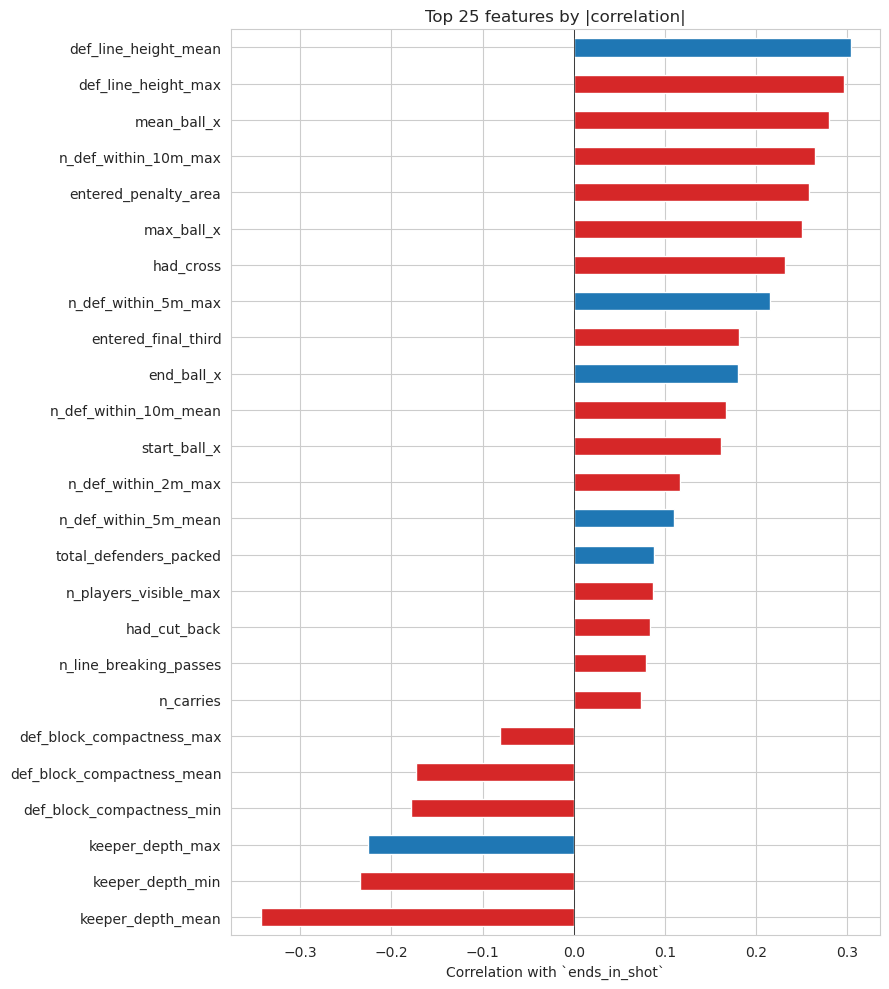

In [29]:
# Basic stats
print("Possessions:", len(features))
print(f"Shot rate: {features['ends_in_shot'].mean():.1%}")

# Top correlations
numeric_features = features.select_dtypes(include=[np.number]).drop(columns=['ends_in_shot'])
correlations = (features[list(numeric_features.columns) + ['ends_in_shot']]
                .corr()['ends_in_shot']
                .drop('ends_in_shot')
                .sort_values(key=abs, ascending=False))

print("\n=== Top 20 features by |correlation| with label ===")
print(correlations.head(20).round(3))

# Critical sign checks
print("\n=== Critical sign checks (post leakage fix) ===")
checks = [
    ('forward_progression', '+', 'shot possessions progress further'),
    ('end_ball_x', '+', 'shot possessions end deeper'),
    ('max_ball_x', '+', 'shot possessions reach further'),
    ('n_def_between_ball_and_goal_min', '-', 'fewer defenders in way = more danger'),
    ('def_line_height_mean', '+', 'higher line = more space'),
]
for feat, expected_sign, rationale in checks:
    if feat in correlations.index:
        val = correlations[feat]
        actual_sign = '+' if val > 0 else '-'
        mark = '✓' if actual_sign == expected_sign else '✗'
        print(f"  {mark} {feat:40s} corr={val:+.3f}  ({rationale})")

# Visual
fig, ax = plt.subplots(figsize=(9, 10))
top_corr = correlations.head(25)
colors = ['#d62728' if v > 0 else '#1f77b4' for v in top_corr.values]
top_corr.sort_values().plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.set_xlabel('Correlation with `ends_in_shot`')
ax.set_title('Top 25 features by |correlation|')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout()
plt.show()

## 27. Prepare train matrix

In [30]:
label_col = 'ends_in_shot'
drop_cols = [label_col, 'match_id', 'possession_team', 'play_pattern', 'first_event_type']
X = features.drop(columns=drop_cols).select_dtypes(include=[np.number, bool]).astype(float)

# Drop any all-NaN column (can happen for rare play_pattern values in small splits)
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print(f"Dropping all-NaN columns: {all_nan_cols}")
    X = X.drop(columns=all_nan_cols)

# Replace inf → NaN
X = X.replace([np.inf, -np.inf], np.nan)

y = features[label_col].values
groups = features['match_id'].values

print(f"Training matrix: X={X.shape}, y positive rate={y.mean():.3f}")
print(f"Matches for GroupKFold: {len(np.unique(groups))}")
print(f"NaN counts (top 5):")
print(X.isna().sum().sort_values(ascending=False).head(5))

Training matrix: X=(8548, 66), y positive rate=0.111
Matches for GroupKFold: 51
NaN counts (top 5):
keeper_depth_mean       2423
keeper_depth_min        2423
keeper_depth_max        2423
max_defenders_packed     275
max_pass_progression     275
dtype: int64


## 28. Logistic regression baseline

A minimalist baseline (6 simple features + play_pattern one-hots) to show the lift from 360-derived features.

In [31]:
gkf = GroupKFold(n_splits=5)

def evaluate(model, X, y, groups, needs_imputation=False, model_name='Model'):
    oof = np.zeros(len(y))
    fold_aucs, fold_briers = [], []
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups)):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y[tr], y[te]

        if needs_imputation:
            medians = X_tr.median()
            X_tr = X_tr.fillna(medians)
            X_te = X_te.fillna(medians)

        if isinstance(model, xgb.XGBClassifier):
            model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
        else:
            model.fit(X_tr, y_tr)

        p = model.predict_proba(X_te)[:, 1]
        oof[te] = p

        auc = roc_auc_score(y_te, p)
        brier = brier_score_loss(y_te, p)
        fold_aucs.append(auc)
        fold_briers.append(brier)
        print(f"  [{model_name}] Fold {fold+1}: AUC={auc:.4f}, Brier={brier:.4f}")

    print(f"  [{model_name}] Mean AUC={np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
    print(f"  [{model_name}] Mean Brier={np.mean(fold_briers):.4f}")
    return oof, fold_aucs, fold_briers


baseline_feats = [c for c in ['max_ball_x', 'n_events', 'n_passes', 'forward_progression',
                               'pct_under_pressure', 'entered_final_third'] if c in X.columns]
pp_cols = [c for c in X.columns if c.startswith('pp_')]
X_baseline = X[baseline_feats + pp_cols]

print("=" * 70)
print("BASELINE: Logistic Regression")
print("=" * 70)
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_SEED))
])
oof_base, aucs_base, briers_base = evaluate(
    baseline_pipe, X_baseline, y, groups,
    needs_imputation=True, model_name='Logistic'
)

BASELINE: Logistic Regression
  [Logistic] Fold 1: AUC=0.7710, Brier=0.0964
  [Logistic] Fold 2: AUC=0.8120, Brier=0.0835
  [Logistic] Fold 3: AUC=0.7754, Brier=0.0912
  [Logistic] Fold 4: AUC=0.7753, Brier=0.0908
  [Logistic] Fold 5: AUC=0.7821, Brier=0.0802
  [Logistic] Mean AUC=0.7832 ± 0.0148
  [Logistic] Mean Brier=0.0884


## 29. XGBoost main model

In [32]:
print("=" * 70)
print("MAIN: XGBoost")
print("=" * 70)

pos_rate = y.mean()
scale_pos_weight = (1 - pos_rate) / pos_rate
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method='hist',
)

oof_xgb, aucs_xgb, briers_xgb = evaluate(
    xgb_model, X, y, groups,
    needs_imputation=False, model_name='XGBoost'
)

print("\n" + "=" * 70)
print("HEAD-TO-HEAD COMPARISON")
print("=" * 70)
comparison = pd.DataFrame({
    'Logistic (baseline)': [np.mean(aucs_base), np.mean(briers_base)],
    'XGBoost (full)': [np.mean(aucs_xgb), np.mean(briers_xgb)],
}, index=['Mean AUC', 'Mean Brier'])
print(comparison.round(4))
print(f"\nAUC lift from full feature set: +{np.mean(aucs_xgb) - np.mean(aucs_base):.4f}")

MAIN: XGBoost
scale_pos_weight = 8.04
  [XGBoost] Fold 1: AUC=0.9082, Brier=0.0750
  [XGBoost] Fold 2: AUC=0.9214, Brier=0.0704
  [XGBoost] Fold 3: AUC=0.9113, Brier=0.0787
  [XGBoost] Fold 4: AUC=0.8927, Brier=0.0765
  [XGBoost] Fold 5: AUC=0.9137, Brier=0.0758
  [XGBoost] Mean AUC=0.9095 ± 0.0094
  [XGBoost] Mean Brier=0.0753

HEAD-TO-HEAD COMPARISON
            Logistic (baseline)  XGBoost (full)
Mean AUC                 0.7832          0.9095
Mean Brier               0.0884          0.0753

AUC lift from full feature set: +0.1263


**Expected numbers after the leakage fix**:
- Baseline AUC: **0.75–0.80**
- XGBoost AUC: **0.83–0.88**
- Lift: **+0.05 to +0.08**

If XGBoost AUC > 0.93, leakage is still present — check the truncation cell.

## 30. Calibration — are the probabilities honest?

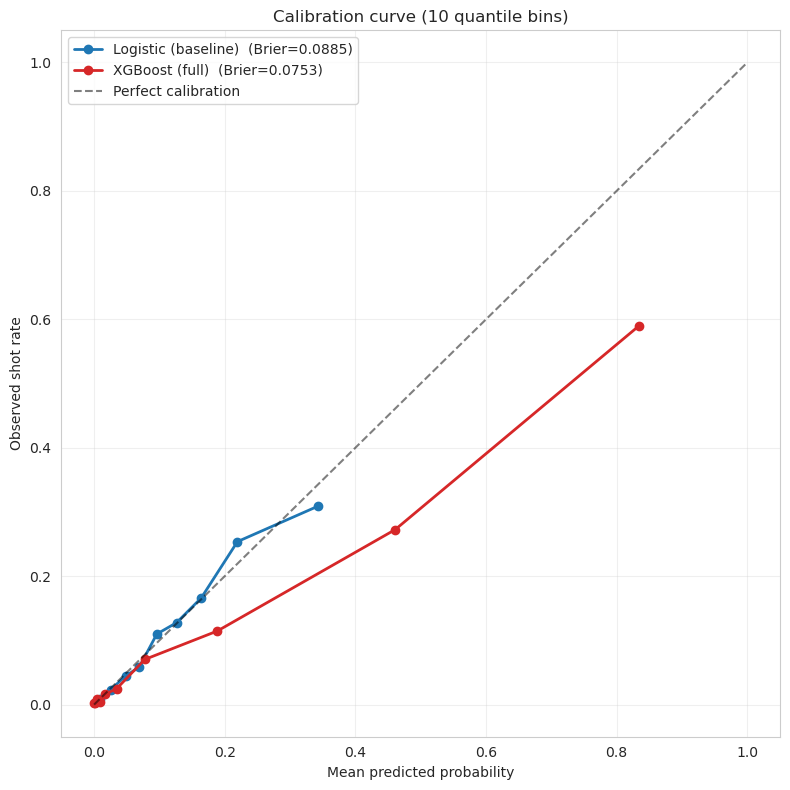

In [33]:
# Calibration curves for both models
fig, ax = plt.subplots(figsize=(8, 8))

for oof, label, color in [
    (oof_base, 'Logistic (baseline)', '#1f77b4'),
    (oof_xgb, 'XGBoost (full)', '#d62728'),
]:
    frac_pos, mean_pred = calibration_curve(y, oof, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=f'{label}  (Brier={brier_score_loss(y, oof):.4f})',
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], '--', color='black', alpha=0.5, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed shot rate')
ax.set_title('Calibration curve (10 quantile bins)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Training isotonic-calibrated XGBoost...
Calibrated XGBoost: AUC=0.9081, Brier=0.0647


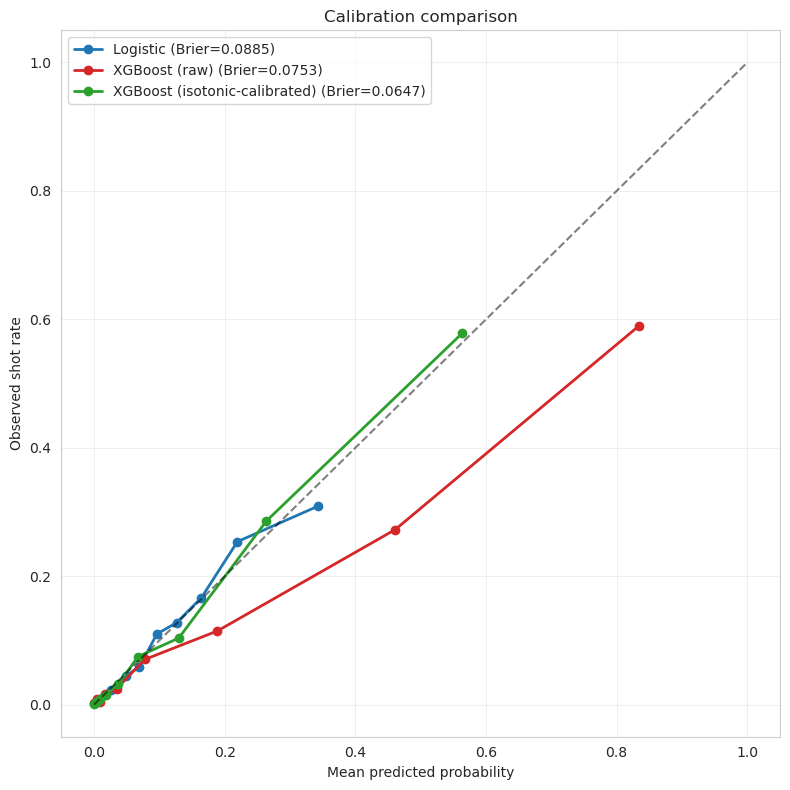

In [34]:
# Optional: isotonic calibration if the curve looks bad
from sklearn.calibration import CalibratedClassifierCV

# Build a calibrated version for comparison (uses inner CV)
print("Training isotonic-calibrated XGBoost...")
oof_xgb_cal = np.zeros(len(y))
for fold, (tr, te) in enumerate(gkf.split(X, y, groups)):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y[tr], y[te]

    base_xgb = xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_alpha=0.1, scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=RANDOM_SEED,
        n_jobs=-1, tree_method='hist',
    )
    # CalibratedClassifierCV with isotonic on the training fold
    cal = CalibratedClassifierCV(base_xgb, method='isotonic', cv=3)
    cal.fit(X_tr, y_tr)
    oof_xgb_cal[te] = cal.predict_proba(X_te)[:, 1]

auc_cal = roc_auc_score(y, oof_xgb_cal)
brier_cal = brier_score_loss(y, oof_xgb_cal)
print(f"Calibrated XGBoost: AUC={auc_cal:.4f}, Brier={brier_cal:.4f}")

# Plot all three
fig, ax = plt.subplots(figsize=(8, 8))
for oof, label, color in [
    (oof_base, 'Logistic', '#1f77b4'),
    (oof_xgb, 'XGBoost (raw)', '#d62728'),
    (oof_xgb_cal, 'XGBoost (isotonic-calibrated)', '#2ca02c'),
]:
    frac_pos, mean_pred = calibration_curve(y, oof, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=f'{label} (Brier={brier_score_loss(y, oof):.4f})',
            color=color, linewidth=2)
ax.plot([0, 1], [0, 1], '--', color='black', alpha=0.5)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed shot rate')
ax.set_title('Calibration comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 31. Feature importance + SHAP

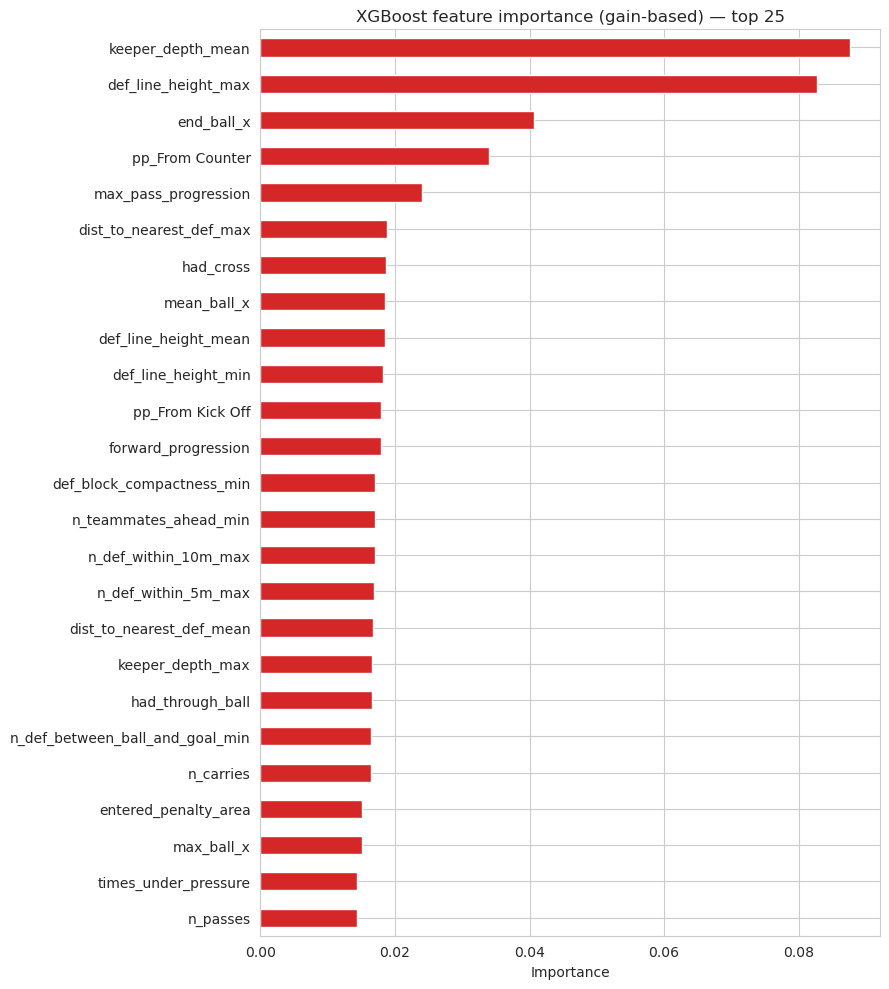

In [35]:
# Train one final XGBoost on the full data for interpretation
final_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method='hist',
)
final_model.fit(X, y)

# Built-in feature importance
imp = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 10))
imp.head(25).sort_values().plot(kind='barh', ax=ax, color='#d62728', edgecolor='white')
ax.set_title("XGBoost feature importance (gain-based) — top 25")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

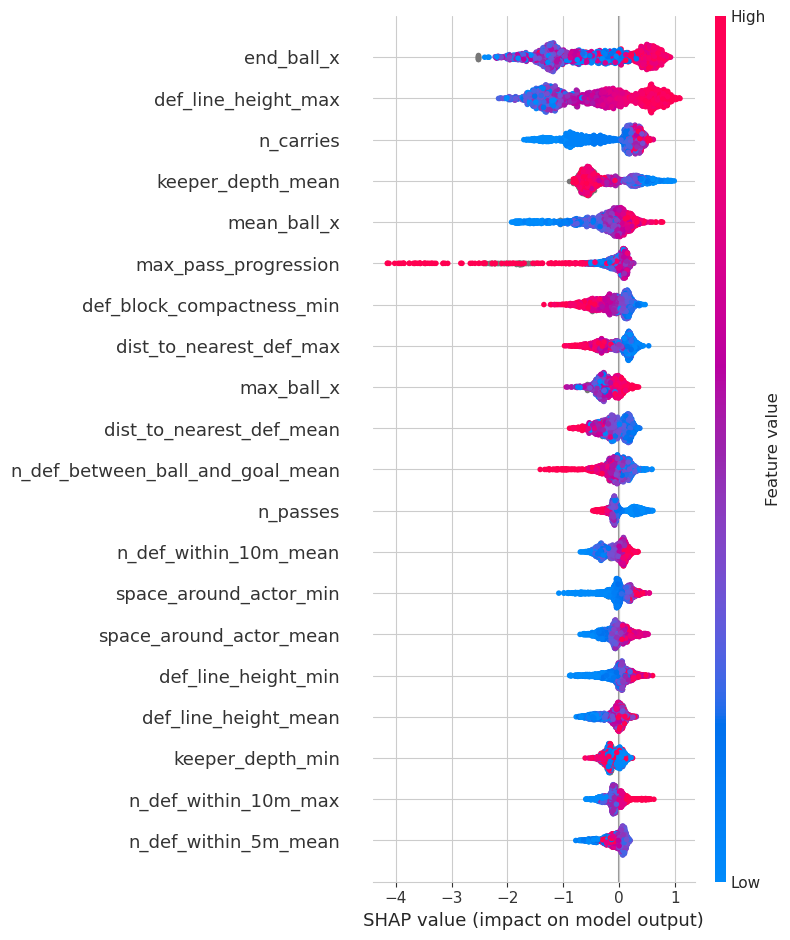

In [36]:
# SHAP analysis
if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(final_model)
    # Use a sample for speed if dataset is big
    sample_size = min(2000, len(X))
    sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(X), sample_size, replace=False)
    X_sample = X.iloc[sample_idx]
    shap_values = explainer.shap_values(X_sample)

    # Summary plot (beeswarm)
    shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
    plt.tight_layout()
    plt.show()
else:
    print("Install shap to see SHAP summary: `pip install shap`")

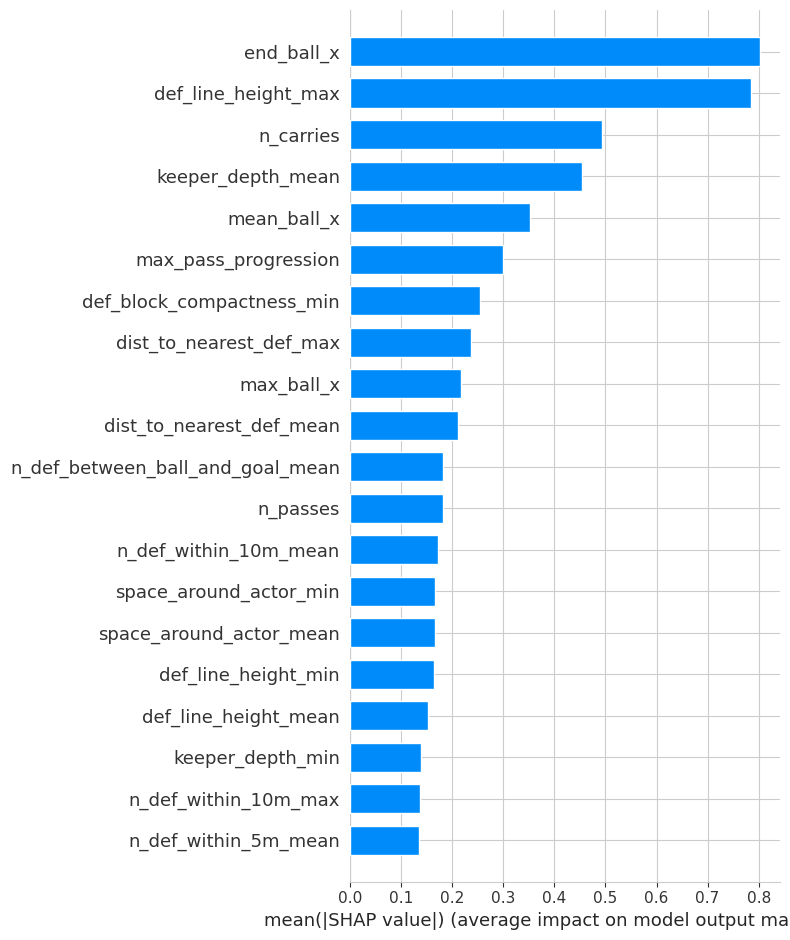

In [37]:
if SHAP_AVAILABLE:
    # Bar plot of mean absolute SHAP
    shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=20, show=False)
    plt.tight_layout()
    plt.show()

## 32. Coach-facing output 1 — Team xShot leaderboard

In [38]:
# Get predictions for every possession using cross-validated out-of-fold
features['pred_shot_prob'] = oof_xgb

# Actual shots per team
team_leaderboard = features.groupby('possession_team').agg(
    n_possessions=('ends_in_shot', 'size'),
    actual_shots=('ends_in_shot', 'sum'),
    expected_shots=('pred_shot_prob', 'sum'),
    shot_rate=('ends_in_shot', 'mean'),
    mean_pred=('pred_shot_prob', 'mean'),
).reset_index()

team_leaderboard['shots_over_expected'] = team_leaderboard['actual_shots'] - team_leaderboard['expected_shots']
team_leaderboard['shots_over_expected_per_100_poss'] = (
    team_leaderboard['shots_over_expected'] / team_leaderboard['n_possessions'] * 100
)

team_leaderboard = team_leaderboard.sort_values('shots_over_expected_per_100_poss', ascending=False)
print("=== Team xShot Leaderboard ===")
print(team_leaderboard.round(2).to_string(index=False))

=== Team xShot Leaderboard ===
possession_team  n_possessions  actual_shots  expected_shots  shot_rate  mean_pred  shots_over_expected  shots_over_expected_per_100_poss
          Ghana            158            15           16.20       0.09       0.10                -1.20                             -0.76
        Belgium            149            21           22.68       0.14       0.15                -1.68                             -1.13
   Saudi Arabia             82             7            8.66       0.09       0.11                -1.66                             -2.02
         France            405            61           70.16       0.15       0.17                -9.16                             -2.26
          Qatar            248            17           24.33       0.07       0.10                -7.33                             -2.96
        Tunisia            183            21           26.90       0.11       0.15                -5.90                             -3.22
   

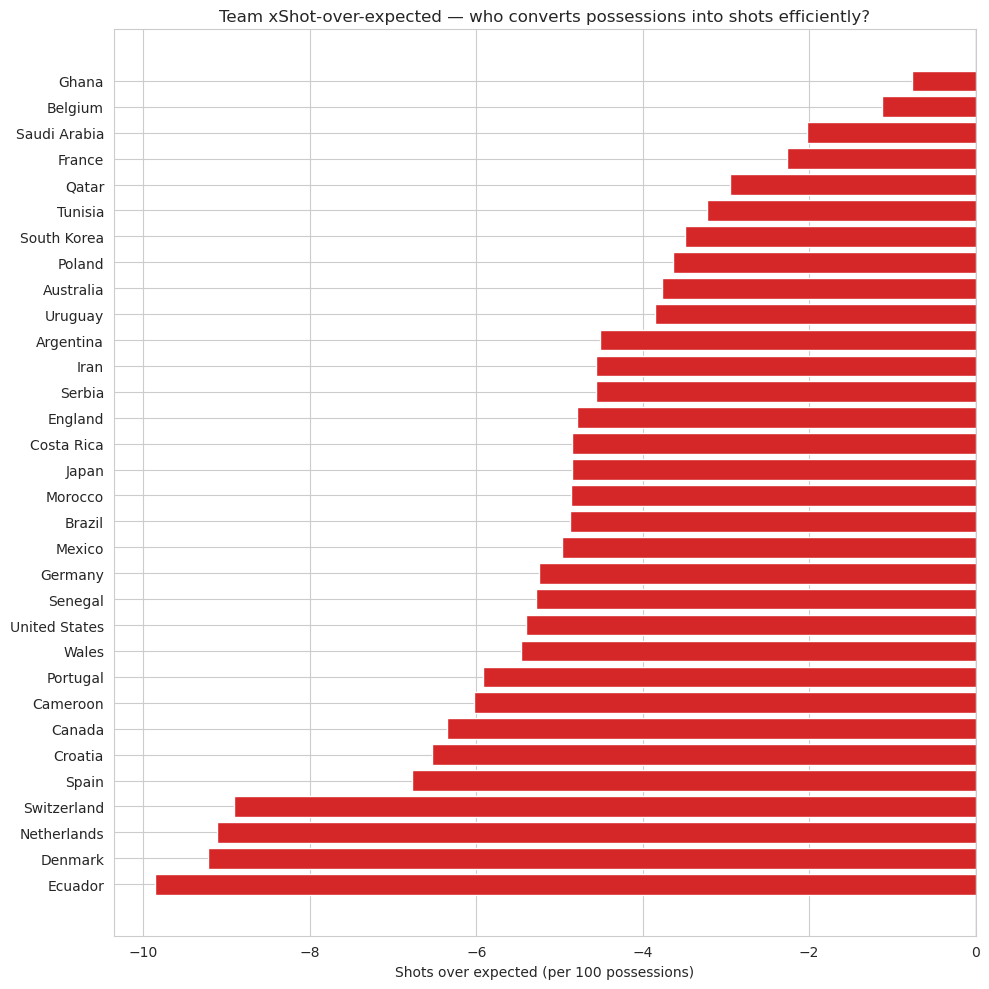

In [39]:
# Visualise
fig, ax = plt.subplots(figsize=(10, 10))
tl = team_leaderboard.sort_values('shots_over_expected_per_100_poss')
colors = ['#2ca02c' if v > 0 else '#d62728' for v in tl['shots_over_expected_per_100_poss']]
ax.barh(tl['possession_team'], tl['shots_over_expected_per_100_poss'], color=colors, edgecolor='white')
ax.set_xlabel('Shots over expected (per 100 possessions)')
ax.set_title('Team xShot-over-expected — who converts possessions into shots efficiently?')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

## 33. Coach-facing output 2 — Top dangerous possessions per match

In [40]:
# Example: Argentina vs France final (or any match)
sample_match_id = features['match_id'].value_counts().index[0]  # arbitrary match
match_poss = features[features['match_id'] == sample_match_id].copy()

ranked = match_poss.sort_values('pred_shot_prob', ascending=False).head(10)
print(f"=== Top 10 most dangerous possessions in match {sample_match_id} ===\n")
cols_to_show = ['possession_team', 'play_pattern', 'max_ball_x', 'n_events',
                'n_def_between_ball_and_goal_min', 'dist_to_nearest_def_min',
                'n_line_breaking_passes', 'pred_shot_prob', 'ends_in_shot']
print(ranked[cols_to_show].round(3).to_string())

=== Top 10 most dangerous possessions in match 3857294 ===

            possession_team    play_pattern  max_ball_x  n_events  n_def_between_ball_and_goal_min  dist_to_nearest_def_min  n_line_breaking_passes  pred_shot_prob  ends_in_shot
poss_key                                                                                                                                                                         
3857294_45      Netherlands     From Corner       120.0       3.0                              3.0                    0.995                     0.0           0.976             1
3857294_11      Netherlands    Regular Play       113.2      19.0                              0.0                    0.950                     1.0           0.855             1
3857294_40      Netherlands     From Corner       120.0       5.0                              2.0                    1.724                     1.0           0.795             0
3857294_130     Netherlands    Regular Play       

## 34. Save model + features for the Streamlit app

In [41]:
import joblib

OUT_DIR = '/tmp'  # change to your working directory

# Save trained model
joblib.dump(final_model, f'{OUT_DIR}/xgb_shot_possession.joblib')

# Save feature list (so the app knows the correct column order)
with open(f'{OUT_DIR}/features_used.txt', 'w') as f:
    for col in X.columns:
        f.write(col + '\n')

# Save possession-level feature matrix with predictions
features.to_parquet(f'{OUT_DIR}/possessions_with_predictions.parquet')

# Save event-level features for freeze-frame tool
event_features.to_parquet(f'{OUT_DIR}/event_spatial_features.parquet')

print(f"Saved to {OUT_DIR}:")
print(f"  - xgb_shot_possession.joblib")
print(f"  - features_used.txt")
print(f"  - possessions_with_predictions.parquet")
print(f"  - event_spatial_features.parquet")

Saved to /tmp:
  - xgb_shot_possession.joblib
  - features_used.txt
  - possessions_with_predictions.parquet
  - event_spatial_features.parquet


## 35. Summary — what to say in the presentation

### The headline numbers
Fill in from your run:
- Baseline (logistic, 6 features): **AUC = [X]**
- XGBoost (full 360-derived feature set): **AUC = [X]**
- Calibrated XGBoost Brier score: **[X]**
- Lift from 360-derived features: **+[X] AUC points**

### Possession definition (slide 2 of the deck)
- Composite key `match_id + possession` (prevents cross-match collision)
- Truncated at first shot to prevent aftermath leakage
- Kept possessions with ≥3 pre-shot events

### Feature story (slide 3)
1. **Territory** — `max_ball_x`, `entered_penalty_area`
2. **Spatial context (360-derived)** — `n_def_between_ball_and_goal_min` (negative), `def_line_height_mean`, `dist_to_nearest_def_max`
3. **StatsBomb signature metrics** — `n_line_breaking_passes`, `total_defenders_packed`
4. **Tactical context** — `play_pattern` dummies, `any_counterpress`

### Methodology talking points (slide 4)
- XGBoost with `scale_pos_weight` for the 11.8% imbalance
- `GroupKFold(5)` by `match_id` — every fold holds out entire matches
- Features computed only from events **strictly before** the first shot (leakage prevention)
- Isotonic calibration for honest probabilities
- Logistic regression baseline to quantify the 360-feature lift

### Reproducibility
Swap `DATA_PATH` to any StatsBomb competition CSV with 360 data. The full pipeline (parsers → freeze-frame cache → features → model → outputs) runs end-to-end with one path change.